Selection:


In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg, merge_cutflows

In [2]:
vr = "31a"
# # Run only once
# process = [
#     "tmu1",
#     "fmu1",
#     "dyj1", 
#     "dyj2",
#     "ttj",
#     "qcd1",
#     "qcd2",
#     "qcd3",
#     "qcd4",
#     # "qcd5",
#     # "qcd6",
#     # "qcd7",
#     # "qcd8",
#     # "qcd9",
#     # "qcd10",
#     # "qcd11",
#     # "qcd12",
# ]

# outall = {}

# for p in process:
#     outp = coffea.util.load(f"outputs/bkg_{vr}_{p}.coffea")
#     outall |= outp

# coffea.util.save(outall, f"outputs/bkg_{vr}.coffea")

output = coffea.util.load(f"outputs/bkg_{vr}.coffea")

In [3]:
# Parameters
# siglxy1 = ["2Mu2E_500GeV_0p25GeV_0p004mm", "2Mu2E_500GeV_0p25GeV_0p04mm", "2Mu2E_500GeV_0p25GeV_0p4mm", "2Mu2E_500GeV_0p25GeV_2p0mm", "2Mu2E_500GeV_0p25GeV_4p0mm"]
siglxy1 = ["2Mu2E_500GeV_0p25GeV_0p004mm",]
bkgttj = ["TTJets"]

bkgdyj = ["DYJetsToMuMu_M10to50", "DYJetsToMuMu_M50"]

bkgqcd = ["QCD_Pt15To20",]# "QCD_Pt20To30", "QCD_Pt30To50", "QCD_Pt50To80", "QCD_Pt80To120", "QCD_Pt120To170", "QCD_Pt170To300", "QCD_Pt300To470", 
          # "QCD_Pt470To600", "QCD_Pt600To800", "QCD_Pt800To1000", "QCD_Pt1000"]

# for 31a
channels = ["bkg_base",
            ########### 2mu
            "bkg_base_2mu2e",
            "bkg_base_2mu2e_iso",
            "bkg_base_2mu2e_iso_disp",
            "bkg_base_2mu2e_iso_disp_dphi",
            ########## 4mu
            # "bkg_base_4mu",
            # "bkg_base_4mu_iso",
            # "bkg_base_4mu_iso_disp",
            # "bkg_base_4mu_iso_disp_dphi",

            
            
]
# for 31
# channels = ["baseNoLj",  # 31
#             "bkg_base", 
#             "bkg_base_iso",
#             "bkg_base_iso_disp",
#             "bkg_base_iso_disp_2mu2e",
#             "bkg_base_iso_disp_2mu2e_dphi",
# ]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]
ch5 = channels[4]


chaname = ["Base", "2mu2e","Iso", "Disp", r"$\Delta\Phi > 2$"]
chan = [ch1, ch2, ch3, ch4, ch5]
histoplot = ["lj_lj_invmass"]
lablxy1 = ["0p3", "3p0", "30", "150", "300"]
colsig=["black", "darkviolet", "navy", "magenta", "darkorange", "darkblue"]
labmx=[r"$2\mu2e: m_{xx}=200$", r"$2\mu2e: m_{xx}=500$", r"$2\mu2e: m_{xx}=800$", r"$2\mu2e: m_{xx}=1000$"]

figh, figw = 12, 10

## Looking at how each selection affect each signal and background process separately

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

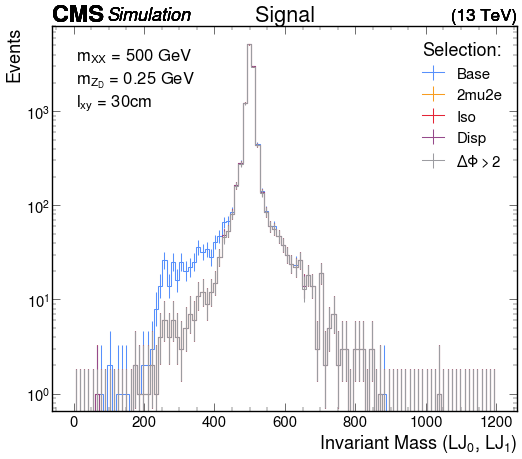

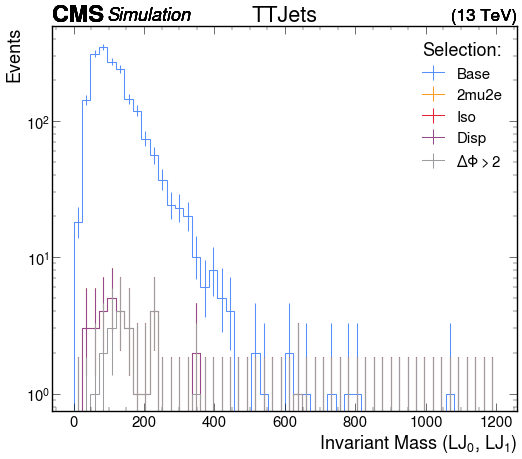

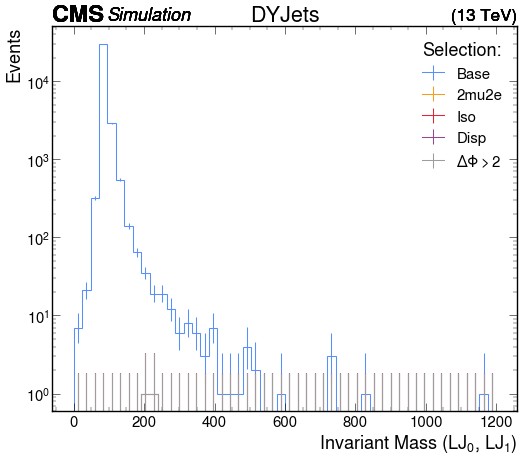

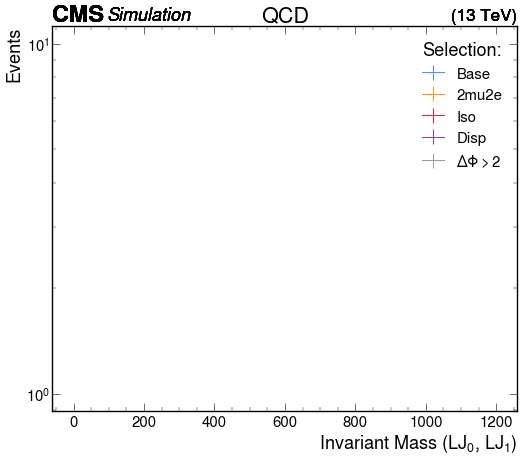

In [4]:
# chan = [ch7]
#tmu signal
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        utilities.plot(output[siglxy1[0]]["hists"][htp][ch, :], label = chaname[ij])
    plt.title("Signal")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)
    plt.text(0.05, 0.95,
             "m$_{XX}$ = 500 GeV\nm$_{Z_D}$ = 0.25 GeV\n$l_{xy}$ = 30cm",
             transform=plt.gca().transAxes,
             fontsize=24,
             va="top"
            )

#TTJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        utilities.plot(TTJ, label = chaname[ij])
    plt.title("TTJets")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

#DYJets
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        utilities.plot(DYJ, label = chaname[ij])
    plt.title("DYJets")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

#QCD
for ik, htp in enumerate(histoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    for ij, ch in enumerate(chan):
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        utilities.plot(QCD, label = chaname[ij])
    plt.title("QCD")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"Selection:", alignment="left", loc=0)

## Stacking Backgrounds for different selections for $m_{xx} = 500$, $m_{z_D} = 0.25$ and changing $l_{xy}$

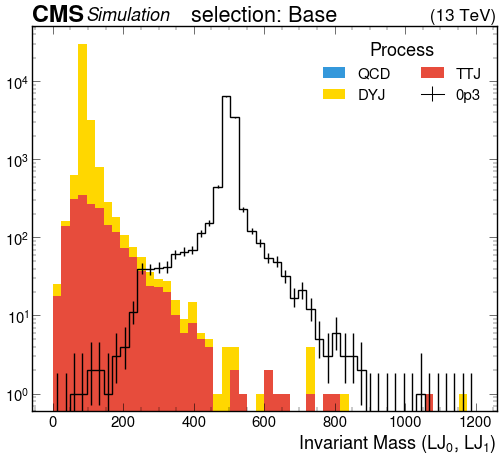

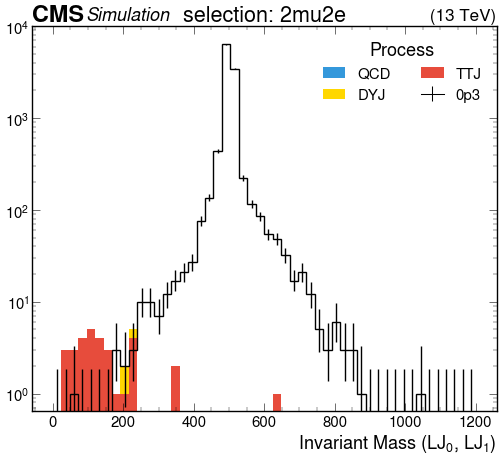

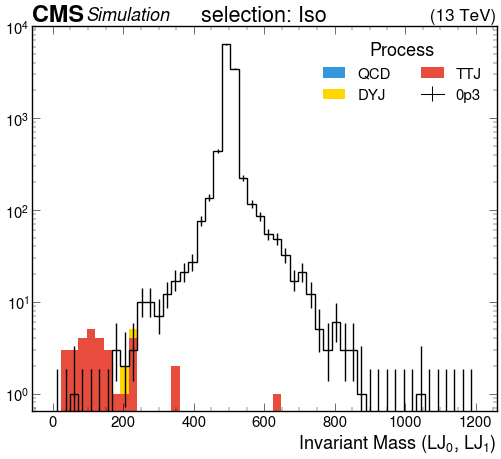

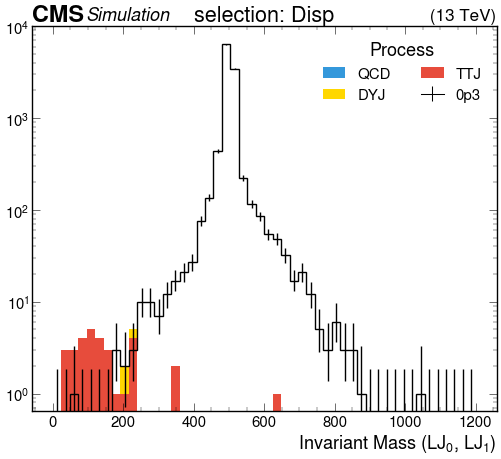

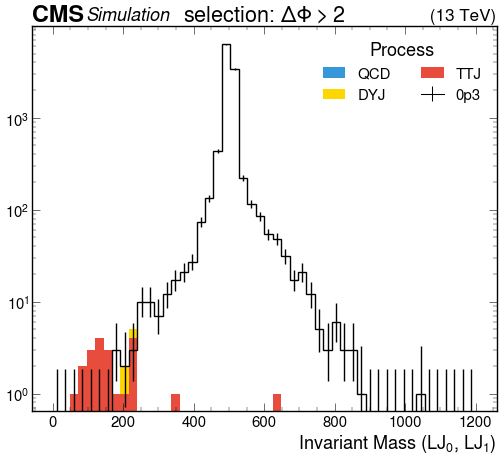

In [5]:
###################################################
####### Stacking Backgrounds diff selections
for htp in histoplot:  
    for ic, ch in enumerate(chan):
        
        fig, ax = plt.subplots(figsize=(figh, figw))
        
        DYJ = merge_bkg(output, bkgdyj, htp, ch)
        QCD = merge_bkg(output, bkgqcd, htp, ch)
        TTJ = merge_bkg(output, bkgttj, htp, ch)
        
        # Backgrounds
        hep.histplot([TTJ, DYJ, QCD,],
                     stack=True,  histtype="fill", 
                     color=["#E74C3C", "#FFD700", "#3498DB"],
                     label=["TTJ", "DYJ", "QCD"],
                     ax=ax, )
        
        # Signal        
        for ix, sss in enumerate(siglxy1):
            hep.histplot(output[sss]["hists"][htp][ch, ::2j],  color=colsig[ix], label=lablxy1[ix], histtype="step", linewidth=2, ax=ax)
        hep.cms.label(data=False, lumi=None, com=13, ax=ax)
        # ax.set_ylim(1, 1000000)
        # ax.yscale(1,10000)
        ax.set_yscale("log")
        ax.legend(title="Process", ncol=2)
        plt.title(f"selection: {chaname[ic]}")
        # plt.savefig(f"clean_plots/fin_bkg_stack_{vr}_{ht}_{cha2name[ic]}_mxx.pdf", bbox_inches="tight", dpi=300)

## More LJ variables for background and signal for final cut only

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


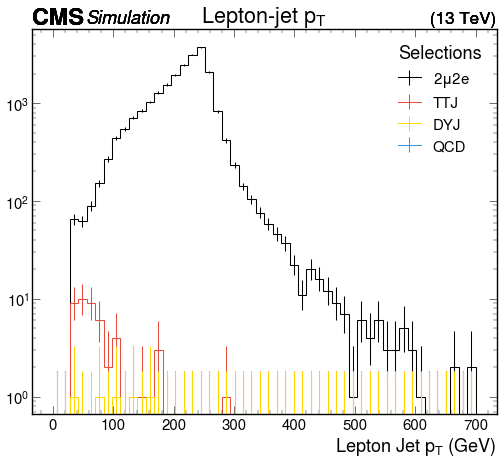

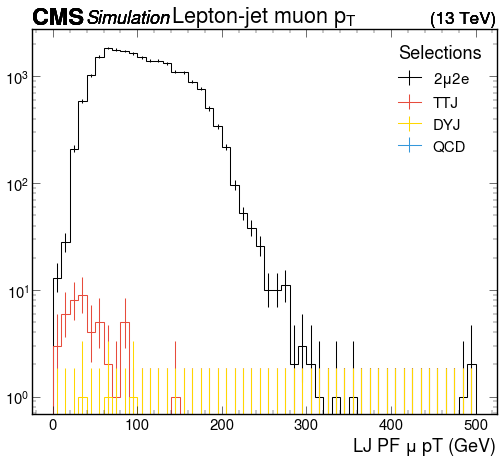

In [6]:
mhtoplot = ["lj_pt", "lj_pfMuon_pt"]
mhtoname = [r"Lepton-jet $p_T$", "Lepton-jet muon $p_T$"]
proname = [r"$2\mu2e"]

ch = ch5
ss = siglxy1[0]

for ih, htp in enumerate(mhtoplot):
    plt.subplots(1, 1, figsize=(figh, figw))
    utilities.plot(output[sss]["hists"][htp][ch, ::2j], label = r"$2\mu2e$", color = "black")

    TTJ = merge_bkg(output, bkgttj, htp, ch)
    utilities.plot(TTJ, label="TTJ", color="#E74C3C")
    
    DYJ = merge_bkg(output, bkgdyj, htp, ch)
    utilities.plot(DYJ, label="DYJ", color="#FFD700")

    QCD = merge_bkg(output, bkgqcd, htp, ch)
    utilities.plot(QCD, label="QCD", color="#3498DB")
    
    plt.yscale("log")
    plt.legend(title="Selections", alignment="left", loc=0)
    plt.title(mhtoname[ih])

## Final yields summary

In [7]:
ch = ch5
dphi = "LJ-LJ dPhi > 2"

print(f"{'Sample':<30} {'Yield':>12}")
print("-" * 44)

# Signal yields
for sample in siglxy1:
    print(f"{sample:<30} {output[sample]['cutflow'][ch].rows[dphi]['weighted']:>12.2f}")
    print("-" * 44)

# Background yields
dyj = merge_cutflows(output, bkgdyj, ch)
ttj = merge_cutflows(output, bkgttj, ch)
qcd = merge_cutflows(output, bkgqcd, ch)

print(f"{'TTJets':<30} {ttj[dphi]['weighted']:>12.2f}")
print("-" * 44)
print(f"{'DYJ':<30}    {dyj[dphi]['weighted']:>12.2f}")
print("-" * 44)
print(f"{'QCD':<30}    {qcd[dphi]['weighted']:>12.2f}")

Sample                                Yield
--------------------------------------------
2Mu2E_500GeV_0p25GeV_0p004mm          32.51
--------------------------------------------
TTJets                              3059.58
--------------------------------------------
DYJ                                    1856.61
--------------------------------------------
QCD                                       0.00


## Number of events after every cut's been applied

In [8]:
for i in siglxy1:
    print(i)
    output[i]["cutflow"][ch].print_table()
    print()

2Mu2E_500GeV_0p25GeV_0p004mm
cut name          raw N    weighted N    weighted %
--------------  -------  ------------  ------------
None            20493.0          59.8         100.0
pass triggers   12175.0          35.5          59.4
PV filter       12175.0          35.5          59.4
>=2 LJs         11575.0          33.8          56.5
2mu2e           11224.0          32.8          54.8
LJ-LJ dPhi > 2  11137.0          32.5          54.3



In [9]:
DYJ = merge_cutflows(output, bkgdyj, ch)
TTJ = merge_cutflows(output, bkgttj, ch)
QCD = merge_cutflows(output, bkgqcd, ch)

backgrounds = {
    "DYJ": bkgdyj,
    "TTJ": bkgttj,
    "QCD": bkgqcd,
}

merged_cf = {}

for name, samples in backgrounds.items():
    merged_cf[name] = merge_cutflows(output, samples, ch)

for name, cf in merged_cf.items():
    print(f"\n{name}")
    print(f"{'cut name':<20} {'raw':>12} {'weighted':>15}")
    print("-" * 50)

    for cut, vals in cf.items():
        print(
            f"{cut:<20}"
            f"{vals['raw']:>12,.0f}"
            f"{vals['weighted']:>15,.1f}"
        )


DYJ
cut name                      raw        weighted
--------------------------------------------------
None                      86,614   75,826,240.0
pass triggers             42,939   36,399,436.0
PV filter                 42,939   36,399,436.0
>=2 LJs                   34,233   28,358,828.0
2mu2e                          2        1,856.6
LJ-LJ dPhi > 2                 2        1,856.6

TTJ
cut name                      raw        weighted
--------------------------------------------------
None                      53,203    7,751,379.0
pass triggers              3,356      488,950.4
PV filter                  3,356      488,950.4
>=2 LJs                    1,874      273,031.3
2mu2e                         31        4,516.5
LJ-LJ dPhi > 2                21        3,059.6

QCD
cut name                      raw        weighted
--------------------------------------------------
None                           7   22,589,406.0
pass triggers                  2    6,454,116.0
PV filter 

In [10]:
all_bkgs = bkgdyj + bkgttj + bkgqcd
total_bkg = merge_cutflows(output, all_bkgs, ch)

for cut, vals in total_bkg.items():
    print(
        f"{cut:<20}"
        f"{vals['raw']:>12,.0f}"
        f"{vals['weighted']:>15,.1f}"
    )

None                     139,824  106,167,024.0
pass triggers             46,297   43,342,504.0
PV filter                 46,297   43,342,504.0
>=2 LJs                   36,107   28,631,860.0
2mu2e                         33        6,373.1
LJ-LJ dPhi > 2                23        4,916.2
